# Linear Regression 1 - Theory & Mathematical Intuition

> **MLCourse · Machine Learning · 01_linear_regression**

The theory backbone for this entire section. Every equation here is derived,
visualized on REAL data, and immediately connected to practice.

## What you'll learn
- What regression models, and the line-of-best-fit intuition
- Hypothesis notation: from $h_\theta(x)=\theta_0+\theta_1x$ to matrix form $X\theta$
- The MSE cost function: why squared errors, full derivation
- Solver A - **Normal Equation**: $\nabla J=0 \Rightarrow \theta=(X^TX)^{-1}X^Ty$ derived & caveated
- Solver B - **Gradient Descent**: update rule, learning-rate effects, batch/SGD/mini-batch
- The five assumptions + a diagnostic for each, on real data
- Metrics: MAE, MSE, RMSE, $R^2$, adjusted $R^2$ - formulas and judgment
- Use cases, when-to-use / when-to-avoid, and a regularization preview

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats                      # Q-Q plotting (ships with sklearn)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def load(name):
    try:
        return sns.load_dataset(name)
    except Exception as e:
        print(f"offline? ({e})")
        return pd.DataFrame()

tips = load("tips")                          # real restaurant data, cached locally

## 1. Intuition - drawing the "best" line through data

**What:** regression predicts a continuous NUMBER ($y \in \mathbb{R}$).
Linear regression assumes that number is a **weighted sum of inputs plus noise**:

$$\text{tip} \approx w_0 + w_1\cdot\text{bill}$$

**Why it matters:** it is the reference model of applied ML - fast, interpretable,
and the baseline every fancier model must beat.

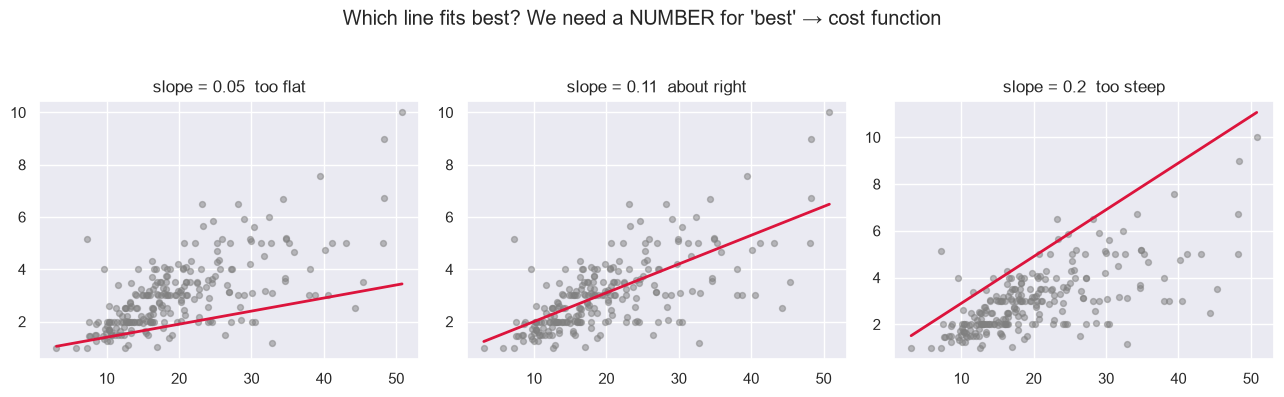

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, w1 in zip(axes, [0.05, 0.11, 0.20]):
    ax.scatter(tips["total_bill"], tips["tip"], s=18, alpha=.5, color="gray")
    xs = np.linspace(tips.total_bill.min(), tips.total_bill.max(), 50)
    ax.plot(xs, 0.9 + w1 * xs, color="crimson", lw=2)
    ax.set_title(f"slope = {w1}  {'too flat' if w1==0.05 else 'about right' if w1==0.11 else 'too steep'}")

fig.suptitle("Which line fits best? We need a NUMBER for 'best' → cost function", y=1.04)
plt.tight_layout(); plt.show()

## 2. Notation & the hypothesis

| Symbol | Meaning |
|---|---|
| $m$ | number of training examples |
| $n$ | number of features |
| $x^{(i)}$ | feature vector of example $i$ |
| $y^{(i)}$ | true target of example $i$ |
| $\theta$ | parameter vector $(w_0=\text{intercept}, w_1..w_n)$ |

Simple model: $h_\theta(x) = \theta_0 + \theta_1 x$

Multiple features: $h_\theta(x) = \theta_0 + \theta_1x_1 + \cdots + \theta_nx_n$

### Matrix form (the one used everywhere in code)

Augment every row with a constant 1 so the intercept becomes just another weight:

$$X = \begin{bmatrix} 1 & x^{(1)}_1 & \cdots & x^{(1)}_n\\ \vdots\\ 1 & x^{(m)}_1 & \cdots & x^{(m)}_n \end{bmatrix}\in\mathbb{R}^{m\times(n+1)},\qquad
h_\theta(X) = X\theta$$

In [3]:
# Build the design matrix for tips: [1, total_bill]
X_demo = np.column_stack([np.ones(len(tips)), tips["total_bill"].values])
y_demo = tips["tip"].values

print("X shape:", X_demo.shape, "| first two rows:")
print(X_demo[:2])

# One matrix multiply produces EVERY prediction at once:
theta_guess = np.array([0.9, 0.11])                 # our middle panel guess
preds = X_demo @ theta_guess                        # (244,) vectorized h(x)
print("first 3 predictions:", preds[:3].round(2))

X shape: (244, 2) | first two rows:
[[ 1.   16.99]
 [ 1.   10.34]]
first 3 predictions: [2.77 2.04 3.21]


## 3. The cost function - measuring 'badness'

Residual for example $i$: $r_i = y^{(i)} - h_\theta(x^{(i)})$.

**MSE** (mean squared error), with the convenient $\tfrac{1}{2}$:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\big(h_\theta(x^{(i)})-y^{(i)}\big)^2
           = \frac{1}{2m}\lVert X\theta-y\rVert^2$$

Why SQUARED errors?
1. differentiable everywhere (absolute value has a kink at 0),
2. penalizes large mistakes disproportionately,
3. makes $J$ a smooth convex parabola in each parameter → ONE global minimum.

D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


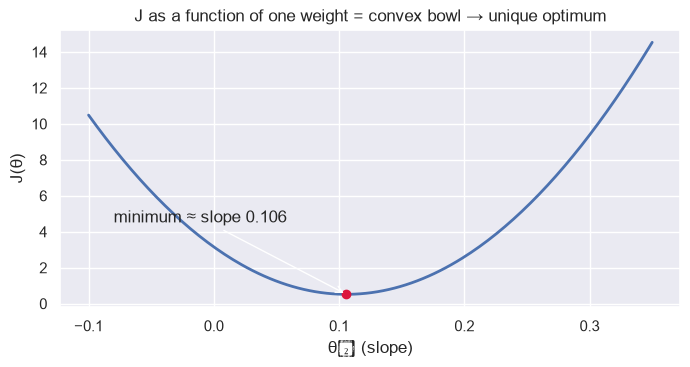

In [4]:
# Watch J(theta1) trace a perfect parabola on real data (intercept fixed at 0.9):
slopes = np.linspace(-0.1, 0.35, 200)
costs = [((y_demo - (0.9 + w * tips["total_bill"].values)) ** 2).mean() / 2
         for w in slopes]

plt.figure(figsize=(8, 3.6))
plt.plot(slopes, costs, lw=2)
w_star = slopes[int(np.argmin(costs))]
plt.scatter([w_star], [min(costs)], color="crimson", zorder=3)
plt.annotate(f"minimum ≈ slope {w_star:.3f}", (w_star, min(costs)),
             xytext=(-0.08, min(costs)+4),
             arrowprops=dict(arrowstyle="->"))
plt.xlabel("θ₁ (slope)"); plt.ylabel("J(θ)")
plt.title("J as a function of one weight = convex bowl → unique optimum")
plt.show()

## 4. Solver A - the Normal Equation (exact answer, no loop)

Differentiate $J(\theta)$ with respect to $\theta$ (matrix calculus):

$$\nabla J(\theta) = \frac{1}{m}X^T(X\theta - y)$$

Set it to ZERO (the minimum of a convex function):

$$X^TX\theta = X^Ty \;\Rightarrow\;
\boxed{\;\theta^* = (X^TX)^{-1}X^Ty\;}$$

This is ordinary least squares (OLS). sklearn's `LinearRegression` solves an
equivalent system via SVD (`np.linalg.lstsq`) - numerically safer than the
literal inverse.

In [5]:
# Solve OLS by hand on the real tips data:
XtX = X_demo.T @ X_demo
Xty = X_demo.T @ y_demo
theta_star = np.linalg.inv(XtX) @ Xty
print("Normal Equation θ* =", theta_star.round(4))

# Same answer from sklearn:
sk = LinearRegression().fit(tips[["total_bill"]], y_demo)
print("sklearn          =", [round(sk.intercept_, 4), round(sk.coef_[0], 4)])

Normal Equation θ* = [0.9203 0.105 ]
sklearn          = [np.float64(0.9203), np.float64(0.105)]


> ⚠️ **Common pitfall / limits of the closed form:**
> - $(X^TX)^{-1}$ may not EXIST when features are perfectly collinear or when
>   $n>m$. Regularization (notebooks 04-06) fixes exactly this.
> - Inverting costs $O(p^3)$ - fine for hundreds of features, painful for millions.

## 5. Solver B - Gradient Descent (iterative, scales anywhere)

Idea: walk downhill on $J$ using its gradient:

$$\theta := \theta - \alpha\,\nabla J(\theta)
           = \theta - \frac{\alpha}{m}X^T(X\theta-y)$$

$\alpha$ = learning rate. Too small → crawling; too large → overshoot/diverge.

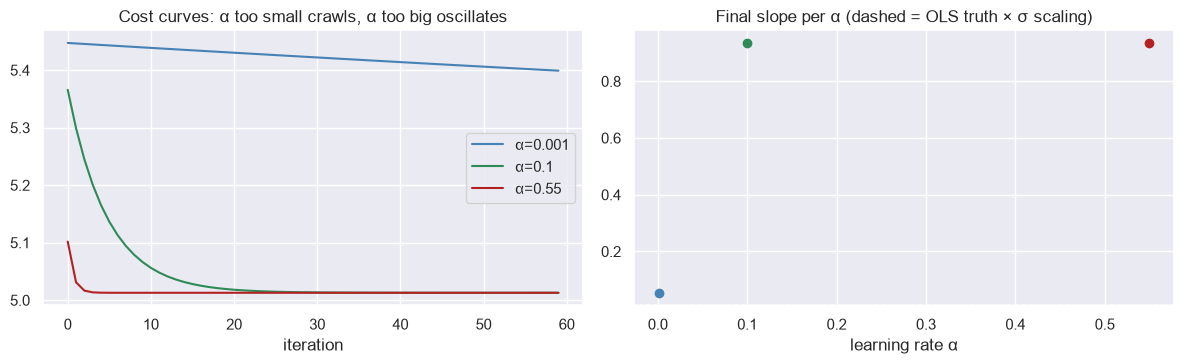

In [6]:
def gradient_descent(X, y, lr=0.1, n_iters=300):
    """Batch GD on MSE. X must already be scaled & include NO bias column here
    (we standardize first so one lr suits all weights)."""
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    for _ in range(n_iters):
        grad = X.T @ (X @ theta - y) / m          # ∇J - one vectorized line!
        theta -= lr * grad
        history.append(((X @ theta - y) ** 2).mean() / 2)
    return theta, history

# REAL diabetes-style demo needs scaled features; use tips bill standardized:
bill_std = ((tips["total_bill"] - tips["total_bill"].mean())
            / tips["total_bill"].std()).values.reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

for lr, color in [(0.001, "steelblue"), (0.1, "seagreen"), (0.55, "firebrick")]:
    _, hist = gradient_descent(bill_std, y_demo, lr=lr, n_iters=60)
    axes[0].plot(hist, label=f"α={lr}", color=color)
axes[0].set_title("Cost curves: α too small crawls, α too big oscillates")
axes[0].set_xlabel("iteration"); axes[0].legend()

for lr, color in [(0.001, "steelblue"), (0.1, "seagreen"), (0.55, "firebrick")]:
    th, _ = gradient_descent(bill_std, y_demo, lr=lr, n_iters=60)
    axes[1].scatter([lr]*len(th[-3:]), th[-3:], color=color)
axes[1].axhline(sk.coef_[0] / tips["total_bill"].std(), ls="--", c="k", lw=1)
axes[1].set_title("Final slope per α (dashed = OLS truth × σ scaling)")
axes[1].set_xlabel("learning rate α")
plt.tight_layout(); plt.show()

Three flavors of GD you will meet everywhere:

| Variant | Data per update | Pros | Cons |
|---|---|---|---|
| Batch GD | ALL m rows | stable, exact gradient | slow on big data |
| Stochastic (SGD) | 1 random row | cheap updates, escapes saddle | noisy path |
| Mini-batch | ~32-512 rows | GPU-friendly sweet spot | one more hyperparameter |

## 6. Assumptions & their diagnostics (LINE+M)

| # | Assumption | Broken when… | Diagnostic below |
|---|---|---|---|
| L | Linearity | curvature in residuals | residuals vs fitted |
| I | Independence | clustered/time data | domain knowledge, DW stat |
| N | Normal errors | skewed residual histogram / QQ bend | Q-Q plot |
| E | Equal variance (homoscedasticity) | funnel shapes | scale-location |
| M | No multicollinearity | features duplicate info | correlation heatmap + VIF |

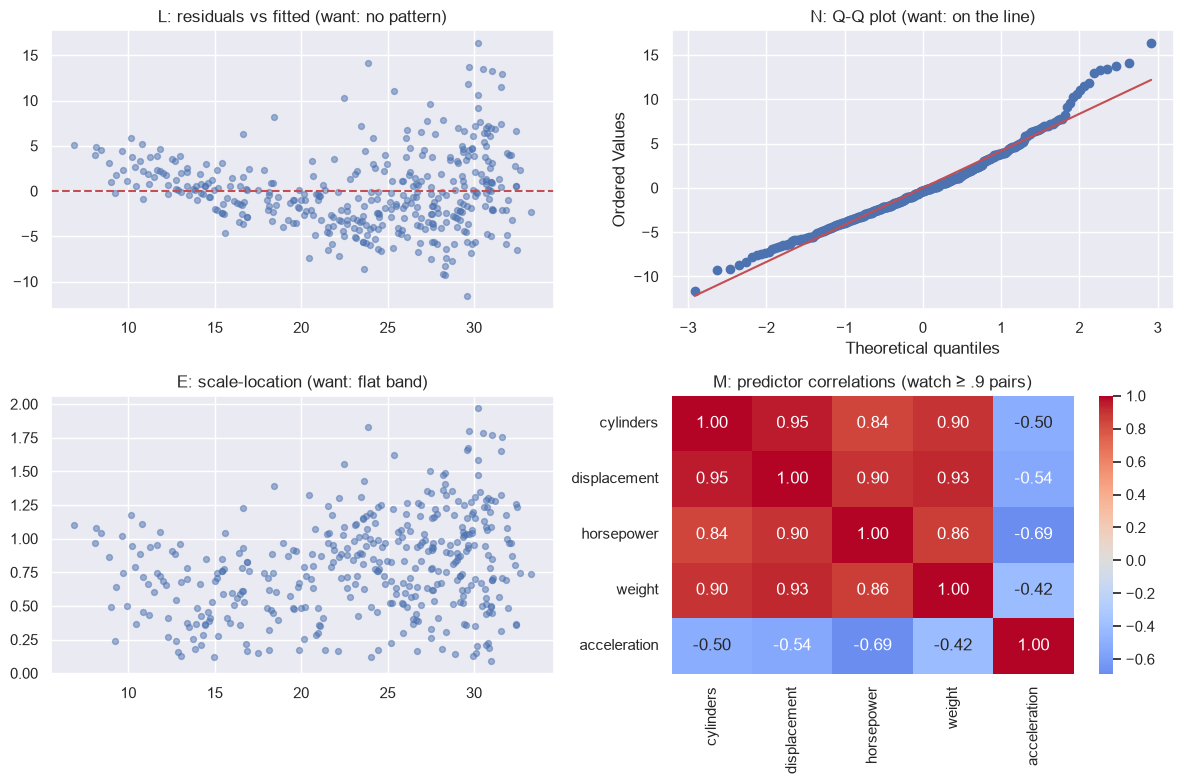

Durbin-Watson (independence proxy, ≈2 good): 0.87


In [7]:
mpg = load("mpg")                                # second real dataset for diagnostics
mpg_c = mpg.dropna(subset=["horsepower"]).copy()
feats = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]

model = LinearRegression().fit(mpg_c[feats], mpg_c["mpg"])
resid = mpg_c["mpg"] - model.predict(mpg_c[feats])
fitted = model.predict(mpg_c[feats])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# L: residual vs fitted - want formless cloud around 0
axes[0, 0].scatter(fitted, resid, alpha=.5, s=18)
axes[0, 0].axhline(0, color="r", ls="--")
axes[0, 0].set_title("L: residuals vs fitted (want: no pattern)")

# N: Q-Q plot - want points on the diagonal
stats.probplot(resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("N: Q-Q plot (want: on the line)")

# E: scale-location - want flat band
sqrt_abs = np.sqrt(np.abs(resid / resid.std()))
axes[1, 0].scatter(fitted, sqrt_abs, alpha=.5, s=18)
axes[1, 0].set_title("E: scale-location (want: flat band)")

# M: correlation heatmap among predictors
sns.heatmap(mpg_c[feats].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1, 1])
axes[1, 1].set_title("M: predictor correlations (watch ≥ .9 pairs)")

plt.tight_layout(); plt.show()
print(f"Durbin-Watson (independence proxy, ≈2 good): "
      f"{np.sum(np.diff(resid.values)**2)/np.sum(resid.values**2):.2f}")

### Variance Inflation Factor - quantifying multicollinearity

Regress each predictor on all others; $VIF_j = 1/(1-R^2_j)$.
Rule of thumb: VIF > 10 ⇒ serious collinearity.

In [8]:
vif_rows = []
for f in feats:
    others = [c for c in feats if c != f]
    r2 = LinearRegression().fit(mpg_c[others], mpg_c[f]).score(mpg_c[others], mpg_c[f])
    vif_rows.append({"feature": f, "VIF": round(1/(1-r2), 1)})
pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
# Engine-size trio is massively collinear → Ridge/Lasso territory (nb 04-06).

,feature,VIF
1,displacement,19.5
0,cylinders,10.6
3,weight,10.4
2,horsepower,8.9
4,acceleration,2.6


## 7. Evaluation metrics - formulas & judgment

| Metric | Formula | Reads as | Sensitive to |
|---|---|---|---|
| MAE | $\frac1m\sum\lvert y-\hat y\rvert$ | avg miss in target units | robust to outliers |
| MSE | $\frac1m\sum(y-\hat y)^2$ | squared error | outliers (squared!) |
| RMSE | $\sqrt{\text{MSE}}$ | typical miss, target units | outliers |
| $R^2$ | $1-\frac{\text{SSE}}{\text{SST}}$ | % variance explained vs mean-baseline | adds with ANY extra feature |
| adj.$R^2$ | $1-(1-R^2)\frac{m-1}{m-p-1}$ | R² penalizing feature count | honest model comparison |

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(
    mpg_c[feats], mpg_c["mpg"], test_size=.25, random_state=42)
mfit = LinearRegression().fit(X_tr, y_tr)
pred = mfit.predict(X_te)

mae = mean_absolute_error(y_te, pred)
mse = mean_squared_error(y_te, pred)
rmse = float(np.sqrt(mse))
r2 = r2_score(y_te, pred)
p, m = len(feats), len(y_te)
adj_r2 = 1 - (1-r2)*(m-1)/(m-p-1)

print(pd.Series({"MAE": round(mae,2), "MSE": round(mse,2),
                 "RMSE": round(rmse,2), "R²": round(r2,3),
                 "adj R²": round(adj_r2,3)}))
print("\nbaseline RMSE if we always predicted the MEAN:",
      round(float(np.sqrt(((y_te - y_tr.mean())**2).mean())), 2))

MAE        3.380
MSE       17.160
RMSE       4.140
R²         0.660
adj R²     0.641
dtype: float64

baseline RMSE if we always predicted the MEAN: 7.17


## 8. Use cases & when to choose linear regression

**Great fits**
- Price estimation with clear drivers (housing, insurance premiums)
- Demand / sales forecasting with trend + seasonality dummies
- Marketing-mix attribution (spend → revenue elasticity)
- Risk scoring where regulators demand interpretable coefficients
- Effect estimation in experiments (A/B lift)
- The mandatory FIRST baseline before any complex model

**Think twice when**
- Relationships are strongly nonlinear (trees/kernels/GAMs win)
- Features vastly outnumber rows without regularization
- Target is categorical → logistic regression instead
- Observations are heavily dependent (time series needs dedicated care)

### Decision quick-table

| Situation | Reach for |
|---|---|
| small clean data, need interpretability | plain OLS |
| correlated features, keep them all | **Ridge** (nb 04) |
| many useless features, want selection | **Lasso** (nb 05) |
| groups of correlated features | **ElasticNet** (nb 06) |

## Summary & key takeaways

- LR models targets as weighted sums: $h_\theta(x)=X\theta$ - one matrix multiply.
- 'Best' is DEFINED by $J(\theta)$ = MSE; squaring buys smoothness + convexity.
- Two solvers: exact **Normal Equation** (small p, invertible) vs scalable
  **Gradient Descent** (needs scaled features & tuned α).
- Check LINE+M assumptions with residual-vs-fitted, Q-Q, scale-location,
  correlation/VIF - diagnostics shown on real `mpg` data.
- Report MAE/RMSE together; prefer adjusted $R^2$ when comparing feature sets.
- Perfect collinearity breaks OLS → regularization is next (nb 04-06).